<a href="https://colab.research.google.com/github/ilincabaiasu/IB9AU/blob/main/Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Required Task 4

### Details

Image Classification with an MLP on Fashion-MNIST

**Instructions:**

This problem tests your ability to adapt the image classification code to a new, slightly
more challenging dataset. Fashion-MNIST has the same format as MNIST (28x28
grayscale images, 10 classes) but features clothing items instead of digits, making it a
harder task.

Your Goal: Train an MLP to classify images of clothing from the Fashion-MNIST dataset.

Your Task:
- Load Data: Use torchvision.datasets to load the FashionMNIST dataset. The process is almost identical to how you loaded MNIST. Create training and testing DataLoaders.

- Define a Model: You can reuse the ImageMLP architecture from the tutorial, as the input
(784) and output (10) dimensions are the same.

- Train the Model: Write a training loop using nn.CrossEntropyLoss and the Adam optimizer. Train for 10 epochs.
Evaluate: Calculate and print the final accuracy on the 10,000 test images.
Visualize: Visualize a few correct and incorrect predictions.

Hint: This is a "drop-in replacement" exercise. The vast majority of your MNIST code will work here. You only need to change torchvision.datasets.MNIST to torchvision.datasets.FashionMNIST. Pay attention to how you define and train the model — it should be a multi-class classification setup.



**What I found interesting:**

-  Some of the results are justified: shirts, pullovers, coats & t-shirt accuracy scores are below average because they are less distinguishable from the other clothes (as opposed to trousers, for instance)
- Confusion Matrix shows gray areas of clothing items alike
- Image Classification problem (in general)


### Imports

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# Use GPU if available, otherwise fall back to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### Load Data

In [4]:
# Class names for readable labels
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Transform: convert PIL image to tensor, then normalise
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
# We normalise pixel values from [0, 255] to approximately [-1, 1]
# using `mean=0.5, std=0.5`. This keeps activations in a well-behaved range during the first forward pass and generally speeds up convergence.

# Download and load Fashion-MNIST  ← only line that differs from MNIST tutorial
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

# DataLoaders — shuffle training data each epoch, leave test ordered
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Training samples : {len(train_dataset):,}")
print(f"Test samples     : {len(test_dataset):,}")
print(f"Batches per epoch: {len(train_loader)}")

Training samples : 60,000
Test samples     : 10,000
Batches per epoch: 938


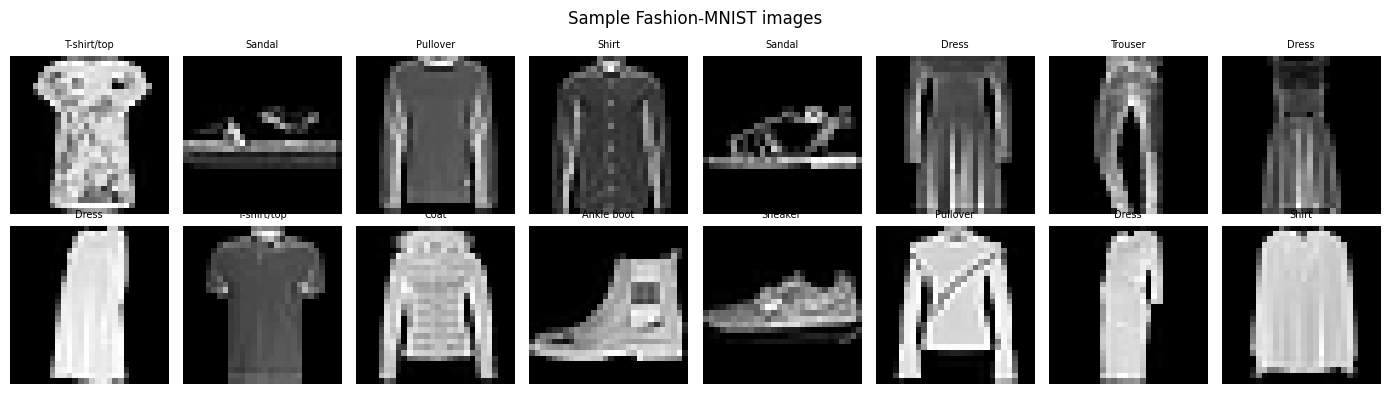

In [5]:
# Preview a sample batch
sample_images, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flatten()):
    # Un-normalise for display: pixel = (tensor * std) + mean
    img = sample_images[i].squeeze().numpy() * 0.5 + 0.5
    ax.imshow(img, cmap='gray')
    ax.set_title(CLASS_NAMES[sample_labels[i].item()], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample Fashion-MNIST images', fontsize=12)
plt.tight_layout()
plt.show()

### Define the MLP

In [6]:
class ImageMLP(nn.Module):
    def __init__(self):
        super(ImageMLP, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),            # (batch, 1, 28, 28) → (batch, 784)
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10)       # 10 logits — one per class
        )

    def forward(self, x):
        return self.model(x)

model = ImageMLP().to(device)
print(model)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

# Notes:
# - The output layer produces **logits** (unnormalised scores), not probabilities. `nn.CrossEntropyLoss` applies softmax internally, so we do not add a softmax here — adding one would be redundant and numerically less stable.
# - Dropout randomly zeroes 20% of neuron outputs during training. This acts as regularisation, reducing overfitting by preventing the network from relying too heavily on any single neuron. It is automatically disabled during evaluation (`model.eval()`).

ImageMLP(
  (model): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=256, out_features=10, bias=True)
  )
)

Trainable parameters: 535,818


### Train model

Notes:

**Loss function:** `nn.CrossEntropyLoss` combines `LogSoftmax` + `NLLLoss` in one numerically stable operation. It expects raw logits as input and integer class indices as targets.

**Optimiser:** Adam adapts the learning rate for each parameter individually using estimates of first and second moments of the gradient. It generally converges faster than plain SGD for this type of problem.

**Training loop per epoch:**
1. Set model to training mode (`model.train()`) — activates dropout
2. For each batch: zero gradients → forward pass → compute loss → backward pass → update weights
3. Set model to evaluation mode (`model.eval()`) — disables dropout
4. Compute accuracy on the test set without tracking gradients (`torch.no_grad()`)

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

NUM_EPOCHS = 10
train_losses = []
test_accuracies = []

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Training ──────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # Clear gradients from previous step
        outputs = model(images)        # Forward pass → logits
        loss = criterion(outputs, labels)  # Compute cross-entropy loss
        loss.backward()                # Backward pass → compute gradients
        optimizer.step()               # Update weights

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ── Evaluation ────────────────────────────────────────────────────────
    model.eval()
    correct = 0
    total   = 0

    with torch.no_grad():              # No gradient tracking needed for inference
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, dim=1)  # Class with highest logit
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    test_accuracies.append(accuracy)

    print(f"Epoch [{epoch:2d}/{NUM_EPOCHS}]  "
          f"Loss: {avg_loss:.4f}  "
          f"Test Accuracy: {accuracy:.2f}%")

print(f"\nFinal test accuracy: {test_accuracies[-1]:.2f}%")

Epoch [ 1/10]  Loss: 0.5178  Test Accuracy: 84.25%
Epoch [ 2/10]  Loss: 0.4011  Test Accuracy: 85.92%
Epoch [ 3/10]  Loss: 0.3623  Test Accuracy: 86.69%
Epoch [ 4/10]  Loss: 0.3453  Test Accuracy: 86.86%
Epoch [ 5/10]  Loss: 0.3256  Test Accuracy: 87.66%
Epoch [ 6/10]  Loss: 0.3158  Test Accuracy: 86.98%
Epoch [ 7/10]  Loss: 0.3016  Test Accuracy: 88.03%
Epoch [ 8/10]  Loss: 0.2951  Test Accuracy: 86.96%
Epoch [ 9/10]  Loss: 0.2837  Test Accuracy: 87.98%
Epoch [10/10]  Loss: 0.2770  Test Accuracy: 87.78%

Final test accuracy: 87.78%


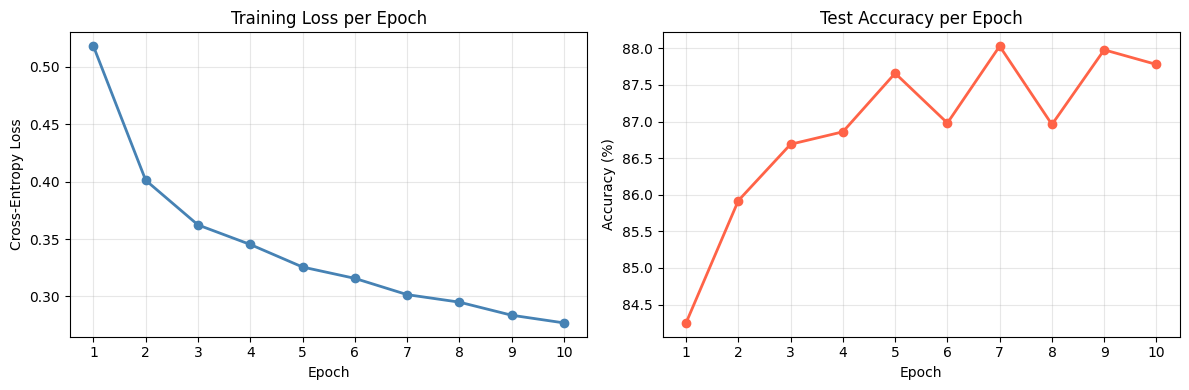

In [8]:
# plotting loss and accuracy over epochs
# - Whether the model is still learning (loss still falling) or has converged
# - Whether accuracy is plateauing — if so, more epochs won't help much
# - Whether there are signs of overfitting (loss falling but accuracy stalling or dropping)

epochs = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(epochs, train_losses, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Training Loss per Epoch', fontsize=12)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_xticks(list(epochs))
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs, test_accuracies, marker='o', color='tomato', linewidth=2)
axes[1].set_title('Test Accuracy per Epoch', fontsize=12)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(list(epochs))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualise correct & incorrect predictions

In [9]:
# Collect all predictions on the test set
model.eval()
all_images, all_labels, all_preds = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        _, preds = torch.max(outputs, dim=1)
        all_images.append(images.cpu())
        all_labels.append(labels.cpu())
        all_preds.append(preds.cpu())

all_images = torch.cat(all_images)
all_labels = torch.cat(all_labels)
all_preds  = torch.cat(all_preds)

# Separate correct and incorrect predictions
correct_mask   = (all_preds == all_labels)
incorrect_mask = ~correct_mask

correct_idx   = correct_mask.nonzero(as_tuple=True)[0]
incorrect_idx = incorrect_mask.nonzero(as_tuple=True)[0]

print(f"Correct predictions  : {correct_mask.sum().item():,}")
print(f"Incorrect predictions: {incorrect_mask.sum().item():,}")

Correct predictions  : 8,778
Incorrect predictions: 1,222


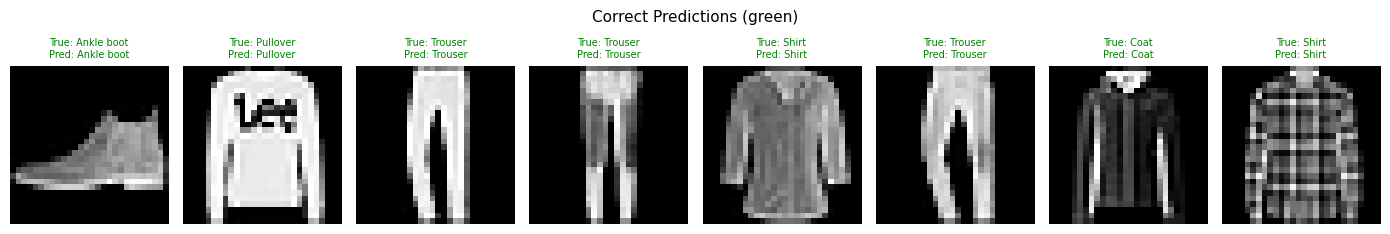

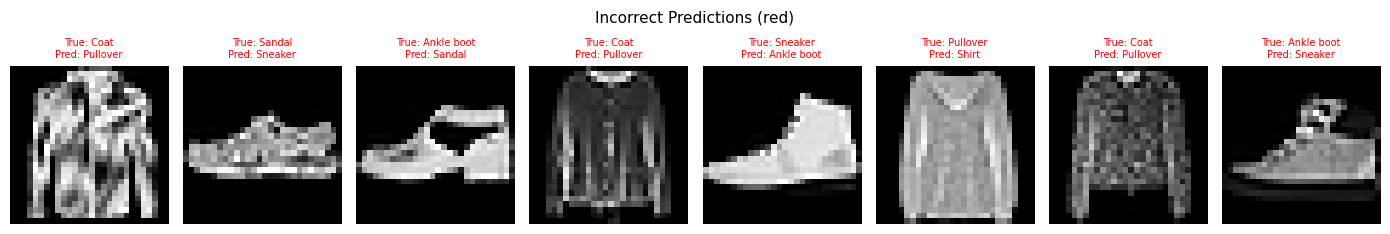

In [10]:
def show_predictions(indices, title, n=8):
    """Plot n sample images with their true and predicted labels."""
    fig, axes = plt.subplots(1, n, figsize=(14, 2.5))
    chosen = indices[:n]
    for ax, idx in zip(axes, chosen):
        img = all_images[idx].squeeze().numpy() * 0.5 + 0.5  # un-normalise
        true_label = CLASS_NAMES[all_labels[idx].item()]
        pred_label = CLASS_NAMES[all_preds[idx].item()]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'True: {true_label}\nPred: {pred_label}',
                     fontsize=7,
                     color='green' if true_label == pred_label else 'red')
        ax.axis('off')
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()

show_predictions(correct_idx,   title='Correct Predictions (green)')
show_predictions(incorrect_idx, title='Incorrect Predictions (red)')

### Confusion Matrix

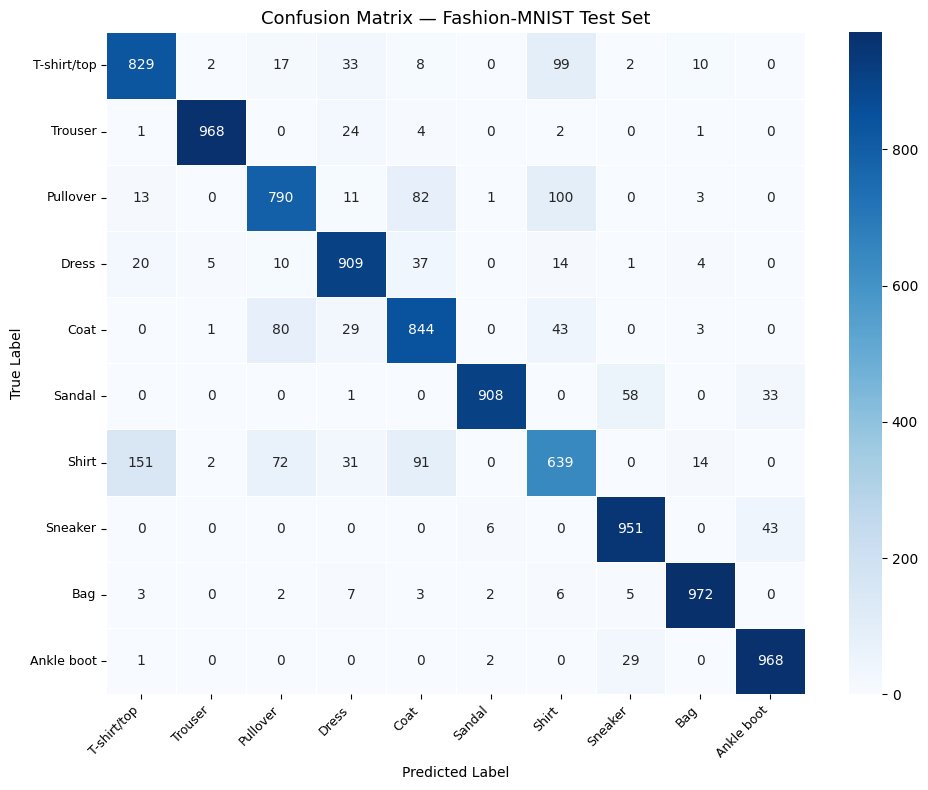

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5
)
plt.title('Confusion Matrix — Fashion-MNIST Test Set', fontsize=13)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### Per-class Accuracy

      Class  Correct  Total  Accuracy (%)
        Bag      972   1000          97.2
    Trouser      968   1000          96.8
 Ankle boot      968   1000          96.8
    Sneaker      951   1000          95.1
      Dress      909   1000          90.9
     Sandal      908   1000          90.8
       Coat      844   1000          84.4
T-shirt/top      829   1000          82.9
   Pullover      790   1000          79.0
      Shirt      639   1000          63.9


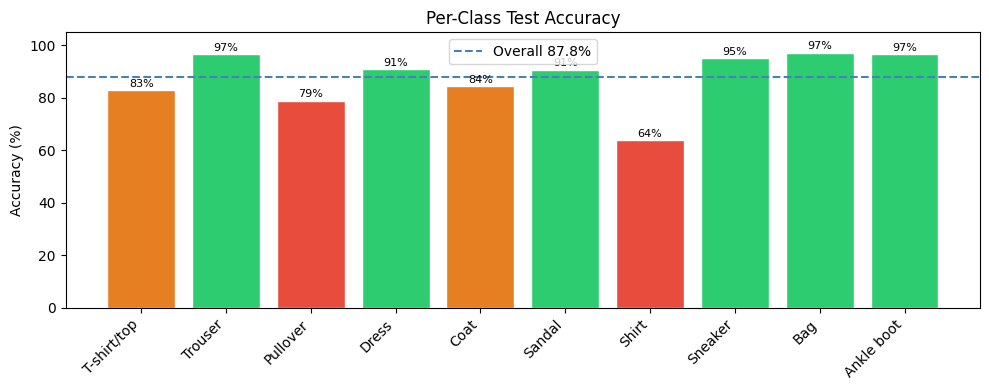

In [12]:
per_class_correct = cm.diagonal()
per_class_total   = cm.sum(axis=1)
per_class_acc     = 100 * per_class_correct / per_class_total

# Display as a sorted table
import pandas as pd
acc_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Correct': per_class_correct,
    'Total': per_class_total,
    'Accuracy (%)': per_class_acc.round(2)
}).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)

print(acc_df.to_string(index=False))

# Bar chart
colors = ['#2ecc71' if a >= 90 else '#e67e22' if a >= 80 else '#e74c3c'
          for a in per_class_acc]
plt.figure(figsize=(10, 4))
bars = plt.bar(CLASS_NAMES, per_class_acc,
               color=[colors[i] for i in range(10)], edgecolor='white')
plt.axhline(test_accuracies[-1], color='steelblue', linestyle='--',
            linewidth=1.5, label=f'Overall {test_accuracies[-1]:.1f}%')
plt.title('Per-Class Test Accuracy', fontsize=12)
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 105)
plt.legend()
for bar, val in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
             f'{val:.0f}%', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()